In [70]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import confusion_table
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import accuracy_score

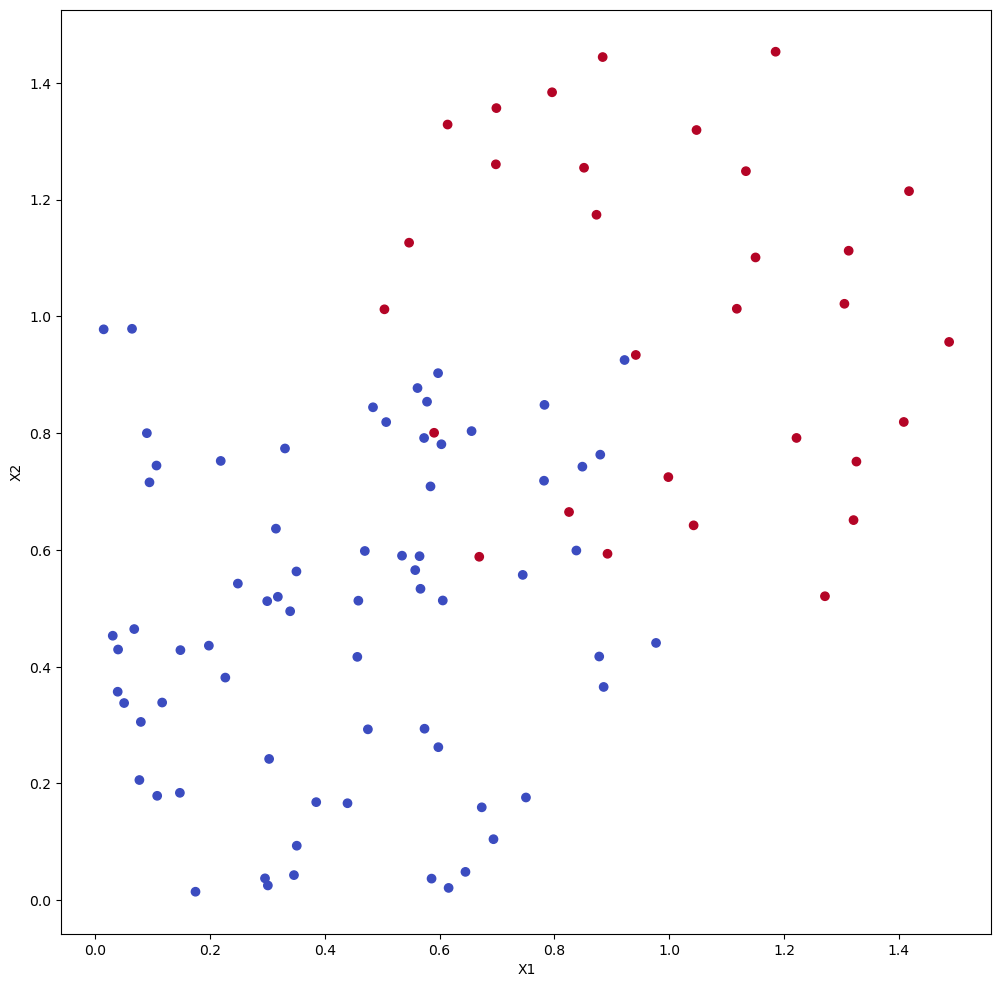

In [72]:
np.random.seed(10)
y=np.concatenate((np.ones(30),np.zeros(70)))
x=np.random.rand(100,2)#
x[y==1] += 0.5
fig,ax=subplots(figsize=(12,12))
ax.scatter(x[:,0],x[:,1],c=y,cmap=cm.coolwarm)
ax.set_xlabel('X1')
ax.set_ylabel('X2');

In [74]:
(X_train,X_test,y_train,y_test)=skm.train_test_split(x,y,test_size=0.5,random_state=11)

In [76]:
# Support vector classifier
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X_train, y_train)

SVC(C=10, kernel='linear')

In [78]:
confusion_table(y_train,svm_linear.predict(X_train))

Truth,0.0,1.0
Predicted,,
0.0,32,3
1.0,3,12


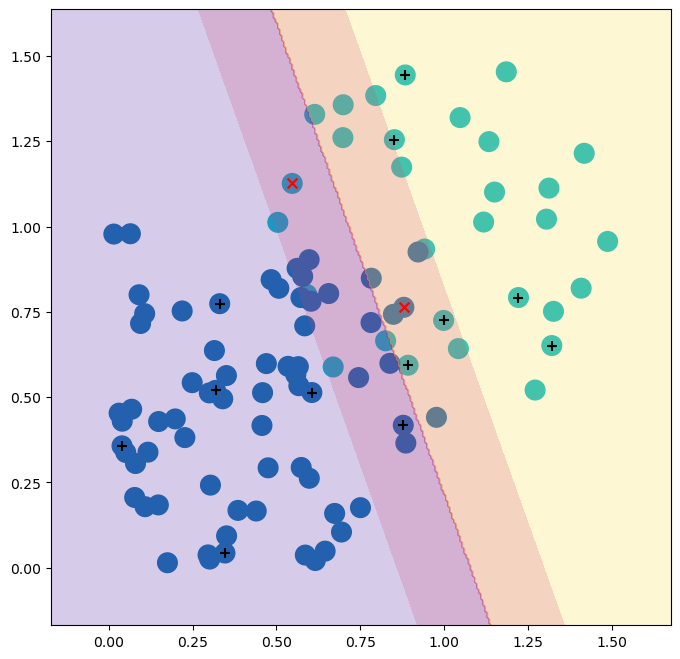

In [80]:
fig, ax = subplots(figsize=(8,8))
plot_svm(x,y,svm_linear,ax=ax)

In [81]:
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid = skm.GridSearchCV(svm_linear,
                        {'C':[0.001,0.01,0.1,1,5,10,100]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(x, y)
grid.best_params_

{'C': 5}

In [84]:
svm_linear1 = SVC(C=5, kernel='linear')
svm_linear1.fit(X_train, y_train)

SVC(C=5, kernel='linear')

In [86]:
confusion_table(y_train,svm_linear1.predict(X_train))

Truth,0.0,1.0
Predicted,,
0.0,34,1
1.0,4,11


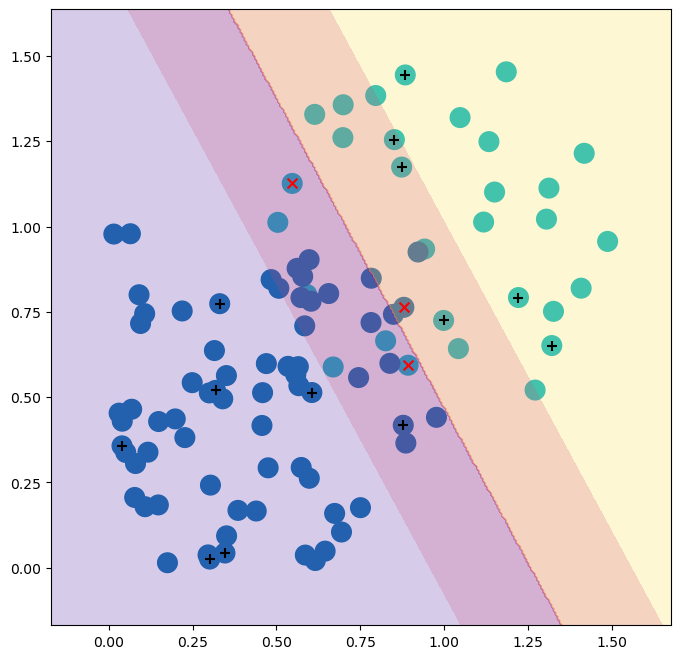

In [88]:
fig, ax = subplots(figsize=(8,8))
plot_svm(x,y,svm_linear1,ax=ax)

In [89]:
svm_poly = SVC(C=10, kernel='poly',degree=4)
svm_poly.fit(X_train, y_train)

SVC(C=10, degree=4, kernel='poly')

In [92]:
confusion_table(y_train,svm_poly.predict(X_train))

Truth,0.0,1.0
Predicted,,
0.0,33,2
1.0,3,12


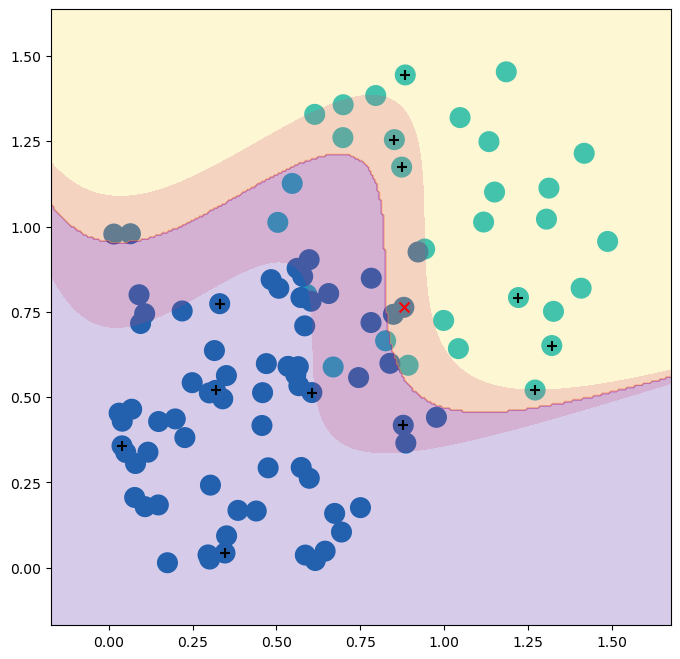

In [94]:
fig, ax = subplots(figsize=(8,8))
plot_svm(x,y,svm_poly,ax=ax);

In [95]:
svm_rbf = SVC(C=10, kernel='rbf',gamma=1.0)
svm_rbf.fit(X_train, y_train)

SVC(C=10, gamma=1.0)

In [98]:
confusion_table(y_train,svm_rbf.predict(X_train))

Truth,0.0,1.0
Predicted,,
0.0,32,3
1.0,3,12


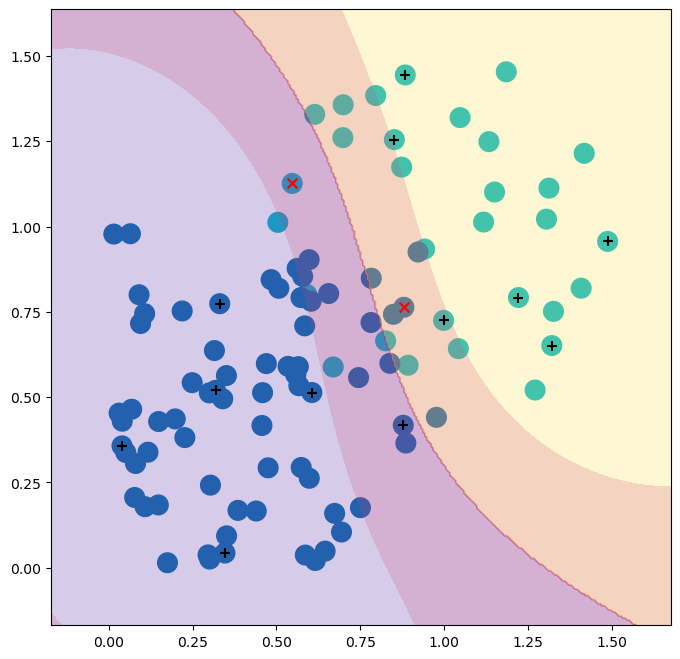

In [100]:
fig, ax = subplots(figsize=(8,8))
plot_svm(x,y,svm_rbf,ax=ax);

In [105]:
method=[svm_linear,svm_linear1,svm_poly,svm_rbf]
Method=['SVC','SVC_Kfold','SVC poly','SVM rbf']
df=pd.DataFrame({'Test error':[1-accuracy_score(y_test, i.predict(X_test)) for i in method]},
                index=Method)
df

,Test error
SVC,0.08
SVC_Kfold,0.06
SVC poly,0.10
SVM rbf,0.08
